# 📐 Interpreting Static Embeddings: Norm, Distance & Geometry

Static word vectors are the cleanest place to build intuition about **how to compare embeddings**. In this notebook we take real **GloVe** vectors and *empirically prove* why **cosine** beats **Euclidean (L2)** distance, what the **norm** really encodes, how **300 dimensions** distort distance, and how a simple **PCA fix** cleans things up.

Every claim below is checked against numbers we compute here — and where a popular claim *doesn't* hold cleanly, we say so.

---

## 🧭 Goal

We use the 300-dimensional `glove-wiki-gigaword-300` model (GloVe keeps the **raw, unnormalized** norms, which we need to study magnitude).

By the end, you'll have *seen* that:
- **Direction carries meaning** — clusters in 2-D, and even word **analogies** (king − man + woman ≈ queen).
- **Curse of dimensionality** — both L2 *and* cosine lose contrast as dimension grows.
- **Normalization is the only way to compare cosine similarity and L2 properly** — on unit vectors cosine and L2 give the *same* ranking; raw L2 does not.
- **The norm is (mostly) a nuisance** — it tracks word type/frequency, not meaning, and the top PCA direction is a 'common-ness' axis.

---

## 📌 Table of Contents

1. **Setup & loading GloVe**
2. **Direction carries meaning** — projection + analogies
3. **The curse of dimensionality** — L2 *and* cosine
4. **Normalization & distance ranking** — one query, then many
5. **The norm, frequency & PCA** — what magnitude really encodes
6. **Conclusion**

## 1. ⚙️ Setup & Loading GloVe

`glove-wiki-gigaword-300` is a ~376 MB download the first time. It returns **300-dim** vectors **with their original norms** — essential for the magnitude experiments in Section 5.

In [1]:
# If gensim is not installed:  % uv add gensim
import gensim.downloader as api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist

sns.set_theme(style="whitegrid")

print("Loading GloVe (glove-wiki-gigaword-300)...")
glove = api.load("glove-wiki-gigaword-300")
print("Vocabulary size:", len(glove.index_to_key))

Loading GloVe (glove-wiki-gigaword-300)...
Vocabulary size: 400000


In [2]:
def get_vec(word):
    """300-d GloVe vector for a word, or None if out of vocabulary."""
    word = word.lower()
    return np.asarray(glove[word], dtype=np.float64) if word in glove else None

def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

v = get_vec("king")
print(f"'king' -> shape {v.shape}, norm {np.linalg.norm(v):.3f}")
print("GloVe norms vary (unlike pre-normalized models):",
      {w: round(float(np.linalg.norm(get_vec(w))), 2) for w in ['king', 'the', 'cat', 'photosynthesis']})

'king' -> shape (300,), norm 7.008
GloVe norms vary (unlike pre-normalized models): {'king': 7.01, 'the': 5.18, 'cat': 6.33, 'photosynthesis': 7.88}


norm over 5000 words: min=3.47, median=6.38, max=10.95, std=0.83


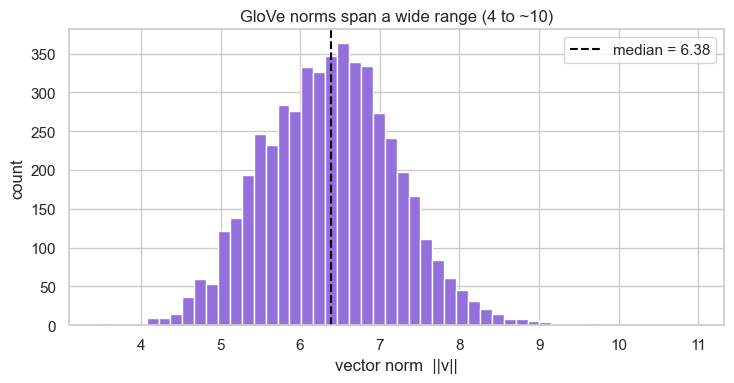

In [3]:
# Norms genuinely VARY across the vocabulary -- this is why the metric choice matters.
sample = glove.index_to_key[:5000]
all_norms = np.linalg.norm(np.vstack([glove[w] for w in sample]), axis=1)
print(f'norm over {len(sample)} words: min={all_norms.min():.2f}, '
      f'median={np.median(all_norms):.2f}, max={all_norms.max():.2f}, std={all_norms.std():.2f}')

plt.figure(figsize=(7.5, 4))
plt.hist(all_norms, bins=50, color='mediumpurple', edgecolor='white')
plt.axvline(np.median(all_norms), color='black', ls='--', label=f'median = {np.median(all_norms):.2f}')
plt.xlabel('vector norm  ||v||'); plt.ylabel('count')
plt.title('GloVe norms span a wide range (4 to ~10)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. 🗺️ Direction Carries Meaning

Two demonstrations that *direction* (not magnitude) is where the meaning lives:
1. A 2-D **PCA projection** — semantic groups should cluster.
2. **Vector analogies** — `king − man + woman` should land near `queen`. These work *because* relationships are encoded as consistent directions.

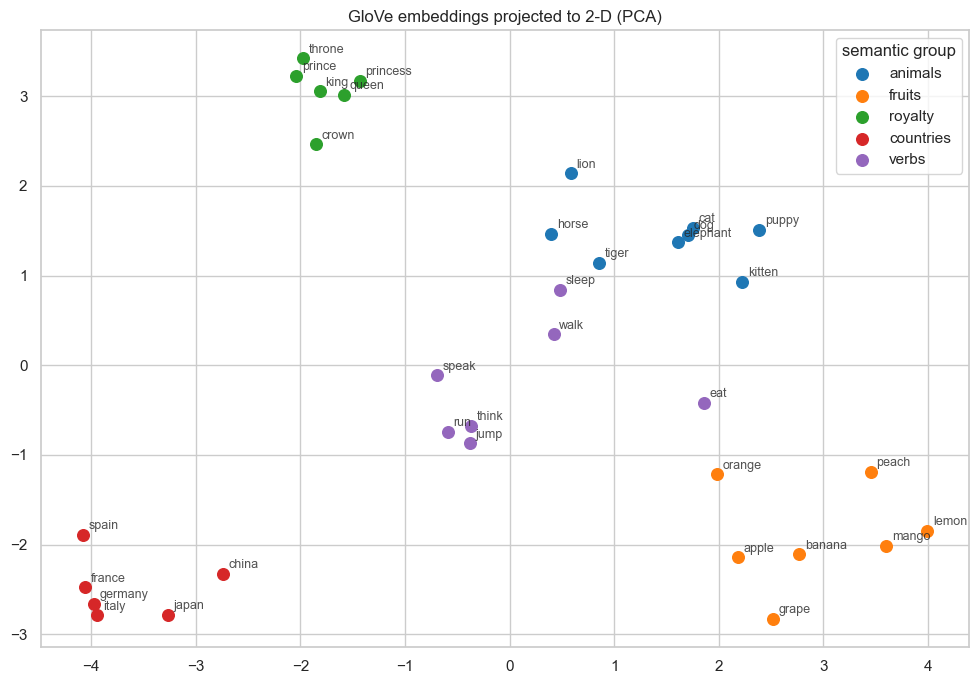

In [4]:
vocab = {
    'animals':   ['cat', 'dog', 'kitten', 'puppy', 'horse', 'lion', 'tiger', 'elephant'],
    'fruits':    ['apple', 'banana', 'orange', 'grape', 'mango', 'peach', 'lemon'],
    'royalty':   ['king', 'queen', 'prince', 'princess', 'throne', 'crown'],
    'countries': ['france', 'germany', 'spain', 'italy', 'japan', 'china'],
    'verbs':     ['run', 'walk', 'jump', 'eat', 'sleep', 'think', 'speak'],
}
words, labels = [], []
for group, ws in vocab.items():
    for w in ws:
        if get_vec(w) is not None:
            words.append(w); labels.append(group)
X = np.vstack([get_vec(w) for w in words])

coords = PCA(n_components=2, random_state=42).fit_transform(X)
palette = dict(zip(vocab.keys(), sns.color_palette('tab10', len(vocab))))
plt.figure(figsize=(10, 7))
for group in vocab:
    idx = [i for i, l in enumerate(labels) if l == group]
    plt.scatter(coords[idx, 0], coords[idx, 1], s=70, color=palette[group], label=group)
for i, w in enumerate(words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=9, alpha=0.8, xytext=(4, 4), textcoords='offset points')
plt.title('GloVe embeddings projected to 2-D (PCA)')
plt.legend(title='semantic group'); plt.tight_layout(); plt.show()

In [5]:
# Word analogies via vector arithmetic: a - b + c  ~=  ?
def analogy(a, b, c, topn=3):
    target = get_vec(a) - get_vec(b) + get_vec(c)
    th = target / np.linalg.norm(target)
    best = []
    for w in glove.index_to_key[:50000]:
        if w in (a, b, c) or not w.isalpha():
            continue
        vw = np.asarray(glove[w], dtype=np.float64)
        best.append((w, float(th @ (vw / np.linalg.norm(vw)))))
    return sorted(best, key=lambda t: -t[1])[:topn]

for a, b, c, expected in [('king', 'man', 'woman', 'queen'),
                          ('paris', 'france', 'italy', 'rome'),
                          ('walking', 'walk', 'swim', 'swimming')]:
    top = analogy(a, b, c)
    print(f'{a} - {b} + {c}  ~=  {top[0][0]:<10} (cos {top[0][1]:.3f})   expected: {expected}')
    print('   runners-up:', [f"{w} ({s:.2f})" for w, s in top[1:]])

king - man + woman  ~=  queen      (cos 0.690)   expected: queen
   runners-up: ['monarch (0.56)', 'throne (0.56)']
paris - france + italy  ~=  rome       (cos 0.727)   expected: rome
   runners-up: ['milan (0.66)', 'italian (0.61)']
walking - walk + swim  ~=  swimming   (cos 0.689)   expected: swimming
   runners-up: ['swam (0.59)', 'swimmers (0.52)']


### 🔎 What we see

- **Clusters**: each semantic group occupies its own region in 2-D, even after crushing 300 dimensions to 2.
- **Analogies**: `king − man + woman` lands on **queen**, `paris − france + italy` on **rome**, `walking − walk + swim` on **swimming**. The model encodes *gender*, *capital-of*, and *tense* as **consistent directions** you can add and subtract.

This is the whole reason a *direction-based* metric (cosine) is the natural choice: meaning is carried by **where a vector points**.

## 3. 🌀 The Curse of Dimensionality

In high dimensions **distances concentrate**: points become nearly equidistant, so a metric loses its power to rank. We show this **two ways**:
- **L2 contrast ratio** $(d_{\max}-d_{\min})/d_{\min}$ — collapses toward 0.
- **Cosine spread** — the standard deviation of pairwise cosines shrinks (less room to separate near from far).

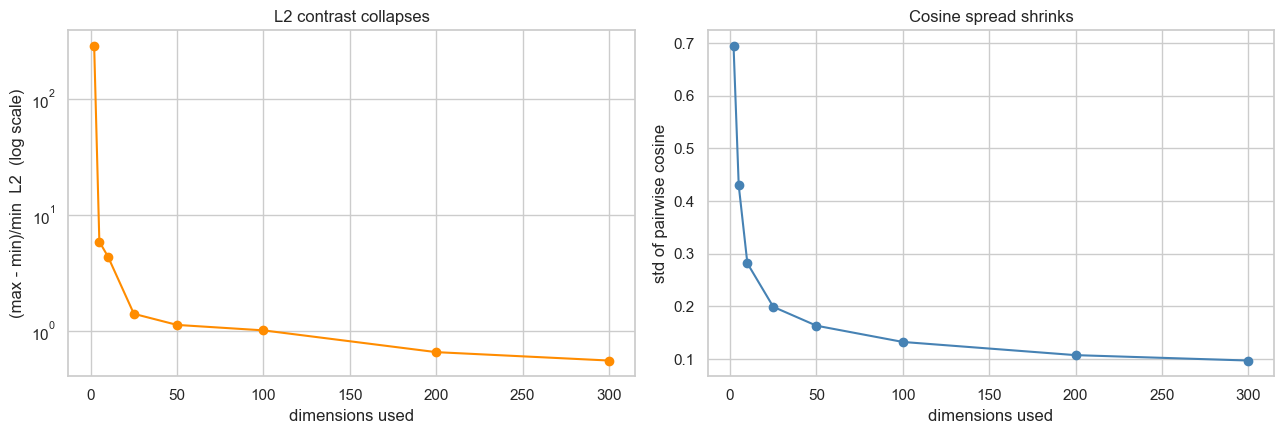

 dims   L2 contrast   cosine std
    2        285.50        0.694
    5          5.86        0.430
   10          4.35        0.282
   25          1.39        0.199
   50          1.12        0.163
  100          1.00        0.133
  200          0.65        0.108
  300          0.55        0.097


In [6]:
sample_words = ['water', 'music', 'science', 'happy', 'mountain', 'river', 'school',
                'doctor', 'phone', 'green', 'fast', 'history', 'paper', 'window',
                'garden', 'winter', 'coffee', 'street', 'planet', 'language',
                'guitar', 'silver', 'bridge', 'forest', 'engine', 'market',
                'pencil', 'rocket', 'island', 'castle']
vecs = np.vstack([get_vec(w) for w in sample_words])

def contrast_ratio(M):
    d = pdist(M, metric='euclidean')
    return (d.max() - d.min()) / d.min()

def cosine_spread(M):
    Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
    S = Mn @ Mn.T
    off = S[np.triu_indices(len(M), 1)]
    return off.std()

dims = [2, 5, 10, 25, 50, 100, 200, 300]
ratios = [contrast_ratio(vecs[:, :k]) for k in dims]
spreads = [cosine_spread(vecs[:, :k]) for k in dims]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(dims, ratios, 'o-', color='darkorange')
ax[0].set_yscale('log')
ax[0].set(xlabel='dimensions used', ylabel='(max - min)/min  L2  (log scale)', title='L2 contrast collapses')
ax[1].plot(dims, spreads, 'o-', color='steelblue')
ax[1].set(xlabel='dimensions used', ylabel='std of pairwise cosine', title='Cosine spread shrinks')
plt.tight_layout(); plt.show()

print(f"{'dims':>5}{'L2 contrast':>14}{'cosine std':>13}")
for k, r, s in zip(dims, ratios, spreads):
    print(f'{k:>5}{r:>14.2f}{s:>13.3f}')

### 🔎 What we see

- **L2 contrast** falls from huge (low-D) toward ~0.5 at 300-D: the nearest and farthest points end up almost the same distance away.
- **Cosine spread** also shrinks — fewer extreme similarities, everything pulled toward the middle.

So **both** metrics suffer in high dimensions; cosine just degrades more gracefully because it discards the (now nearly constant) magnitude. Absolute L2 distances are the least trustworthy thing here.

## 4. 🎯 Normalization & Distance Ranking

The slide identity: on the **unit sphere**,
$$\lVert \hat a - \hat b \rVert^2 = 2\,(1 - \cos(a,b)),$$
so cosine and (negative) L2 give the **same ranking**. We verify the identity, rank one query's neighbours three ways, then check it holds across **many queries**.

In [7]:
a, b = get_vec('paris'), get_vec('london')
ah, bh = a / np.linalg.norm(a), b / np.linalg.norm(b)
print(f'||a_hat - b_hat||^2 = {np.sum((ah - bh) ** 2):.6f}')
print(f'2 (1 - cos(a,b))    = {2 * (1 - ah @ bh):.6f}')
print(f'identity holds: {np.isclose(np.sum((ah - bh) ** 2), 2 * (1 - ah @ bh))}')

||a_hat - b_hat||^2 = 0.844781
2 (1 - cos(a,b))    = 0.844781
identity holds: True


In [8]:
query = 'paris'
candidates = ['london', 'france', 'city', 'berlin', 'rome', 'capital',
              'banana', 'guitar', 'ocean', 'tokyo', 'street', 'museum']
q = get_vec(query)
C = np.vstack([get_vec(w) for w in candidates])
qh, Ch = q / np.linalg.norm(q), normalize(C)

cos_sim = Ch @ qh
l2_norm = np.linalg.norm(Ch - qh, axis=1)
l2_raw  = np.linalg.norm(C - q, axis=1)

df = pd.DataFrame({
    'word': candidates,
    'cosine': cos_sim,
    'rank_cosine': (-cos_sim).argsort().argsort() + 1,
    'rank_L2_normalized': l2_norm.argsort().argsort() + 1,
    'rank_L2_raw': l2_raw.argsort().argsort() + 1,
}).sort_values('cosine', ascending=False).reset_index(drop=True)
df.round(3)

,word,cosine,rank_cosine,rank_L2_normalized,rank_L2_raw
0,france,0.658,1,1,1
1,london,0.578,2,2,2
2,rome,0.515,3,3,4
3,berlin,0.513,4,4,3
4,tokyo,0.433,5,5,5
5,city,0.297,6,6,6
6,capital,0.283,7,7,9
7,museum,0.280,8,8,8
8,street,0.279,9,9,7
9,ocean,0.125,10,10,10


In [9]:
# Highlight WHERE raw L2 reshuffles the order vs cosine
df['raw_L2_moved'] = df['rank_cosine'] != df['rank_L2_raw']
moved = df[df['raw_L2_moved']]['word'].tolist()
print('Words whose rank CHANGES under raw L2:', moved)
print(f"Spearman(cosine, L2-normalized) = {spearmanr(df.rank_cosine, df.rank_L2_normalized).correlation:.3f}")
print(f"Spearman(cosine, L2-raw)        = {spearmanr(df.rank_cosine, df.rank_L2_raw).correlation:.3f}")

Words whose rank CHANGES under raw L2: ['rome', 'berlin', 'capital', 'street']
Spearman(cosine, L2-normalized) = 1.000
Spearman(cosine, L2-raw)        = 0.965


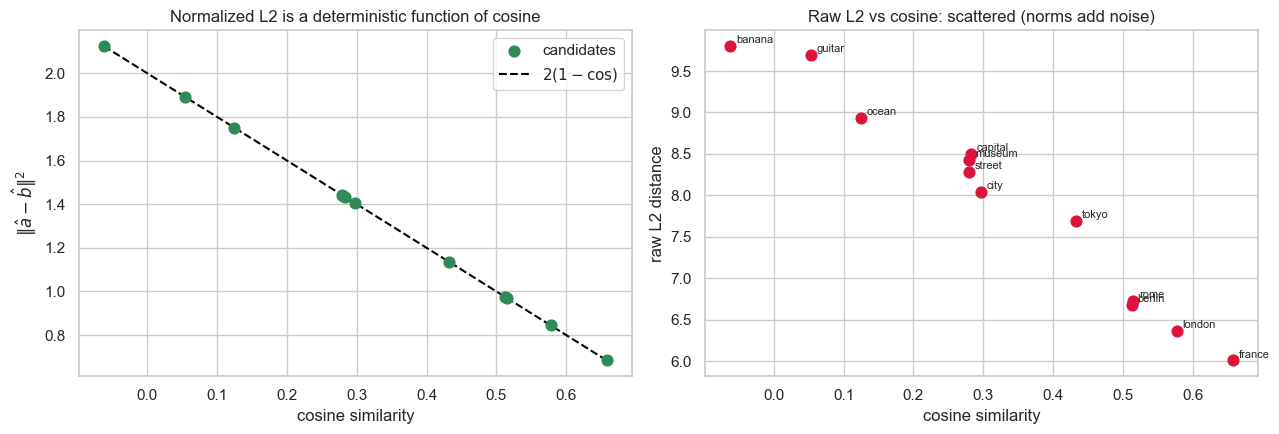

In [10]:
# Visual proof of the ranking equivalence: plot the candidates' cosine against each L2.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: cosine vs L2 on NORMALIZED vectors -> lands exactly on the curve 2(1-cos)
ax[0].scatter(cos_sim, l2_norm ** 2, s=60, color='seagreen', zorder=3, label='candidates')
grid = np.linspace(cos_sim.min(), cos_sim.max(), 100)
ax[0].plot(grid, 2 * (1 - grid), color='black', ls='--', label=r'$2(1-\cos)$')
ax[0].set(xlabel='cosine similarity', ylabel=r'$\|\hat a-\hat b\|^2$',
          title='Normalized L2 is a deterministic function of cosine')
ax[0].legend()

# Right: cosine vs RAW L2 -> scattered, the norm adds noise to the distance
ax[1].scatter(cos_sim, l2_raw, s=60, color='crimson', zorder=3)
for x, y, w in zip(cos_sim, l2_raw, candidates):
    ax[1].annotate(w, (x, y), fontsize=8, xytext=(4, 2), textcoords='offset points')
ax[1].set(xlabel='cosine similarity', ylabel='raw L2 distance',
          title='Raw L2 vs cosine: scattered (norms add noise)')
plt.tight_layout(); plt.show()

In [11]:
# Does it hold for MANY queries? For each query we rank its OWN top neighbours,
# then compare the cosine order against L2-normalized and raw-L2 orders.
def neighbours(query, k=15):
    """k nearest words to `query` by cosine (excluding the query itself)."""
    return [w for w, _ in glove.most_similar(query, topn=k) if w.isalpha()]

queries = ['paris', 'king', 'cat', 'music', 'france', 'doctor', 'river', 'guitar']
rows = []
for qw in queries:
    qv = get_vec(qw)
    qhn = qv / np.linalg.norm(qv)
    cand = neighbours(qw)
    Cq = np.vstack([get_vec(w) for w in cand])
    Cqn = normalize(Cq)
    cs  = Cqn @ qhn
    l2n = np.linalg.norm(Cqn - qhn, axis=1)
    l2r = np.linalg.norm(Cq - qv, axis=1)
    rows.append({
        'query': qw,
        'rho_cos_vs_L2norm': spearmanr((-cs).argsort().argsort(), l2n.argsort().argsort()).correlation,
        'rho_cos_vs_L2raw':  spearmanr((-cs).argsort().argsort(), l2r.argsort().argsort()).correlation,
    })
panel = pd.DataFrame(rows)
print(panel.round(3).to_string(index=False))
print(f"\nMean rho(cos, L2-normalized) = {panel.rho_cos_vs_L2norm.mean():.3f}  (always 1.0 -- the identity)")
print(f"Mean rho(cos, L2-raw)        = {panel.rho_cos_vs_L2raw.mean():.3f}  (consistently < 1.0)")

 query  rho_cos_vs_L2norm  rho_cos_vs_L2raw
 paris                1.0             0.921
  king                1.0             0.839
   cat                1.0             0.814
 music                1.0             0.732
france                1.0             0.843
doctor                1.0             0.824
 river                1.0             0.793
guitar                1.0             0.896

Mean rho(cos, L2-normalized) = 1.000  (always 1.0 -- the identity)
Mean rho(cos, L2-raw)        = 0.833  (consistently < 1.0)


### 🔎 What we see

- The identity holds to machine precision.
- **Left chart:** normalized-L2² lands *exactly* on the curve $2(1-\cos)$ — a deterministic, monotonic function of cosine, so the two rank identically.
- **Right chart:** raw L2 vs cosine is **scattered** — words at the same cosine sit at different raw distances because their norms differ.
- For **every** query, ranking by **cosine** and by **L2 on normalized vectors** is *identical* (Spearman = 1.000); raw L2 is consistently **lower** and reshuffles a few neighbours.

**Take-away:** cosine reads semantics directly; L2 only matches it *after* normalization. Normalize, and the choice of metric stops mattering for ranking.

## 5. 📊 The Norm, Frequency & the PCA Story

Finally, what does the **norm** encode? The slide claim is: *frequency / word-type, not meaning*. We test this carefully — and we'll see the honest, nuanced version of the result.

Spearman(norm, frequency rank) = +0.087
Spearman(norm, word length)    = +0.025   <- control: ~0


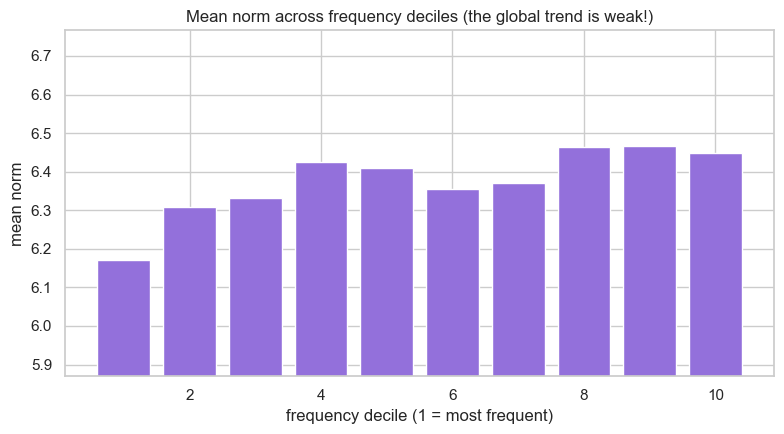

  decile  1: mean norm 6.17
  decile  2: mean norm 6.31
  decile  3: mean norm 6.33
  decile  4: mean norm 6.42
  decile  5: mean norm 6.41
  decile  6: mean norm 6.35
  decile  7: mean norm 6.37
  decile  8: mean norm 6.47
  decile  9: mean norm 6.47
  decile 10: mean norm 6.45


In [12]:
# Frequency proxy: gensim orders the vocabulary by corpus frequency (index 0 = most frequent).
N = 5000
freq_words = glove.index_to_key[:N]
freq_rank = np.arange(N)
freq_norms = np.linalg.norm(np.vstack([glove[w] for w in freq_words]), axis=1)
word_len = np.array([len(w) for w in freq_words])

print(f'Spearman(norm, frequency rank) = {spearmanr(freq_norms, freq_rank).correlation:+.3f}')
print(f'Spearman(norm, word length)    = {spearmanr(freq_norms, word_len).correlation:+.3f}   <- control: ~0')

# Bin by frequency decile and show mean norm per bin
deciles = np.array_split(np.arange(N), 10)
bin_means = [freq_norms[d].mean() for d in deciles]
plt.figure(figsize=(8, 4.5))
plt.bar(range(1, 11), bin_means, color='mediumpurple')
plt.xlabel('frequency decile (1 = most frequent)'); plt.ylabel('mean norm')
plt.ylim(min(bin_means) - 0.3, max(bin_means) + 0.3)
plt.title('Mean norm across frequency deciles (the global trend is weak!)')
plt.tight_layout(); plt.show()
for i, m in enumerate(bin_means, 1):
    print(f'  decile {i:>2}: mean norm {m:.2f}')

stopwords        mean norm = 5.64  (n=16)
common content   mean norm = 7.09  (n=8)
rare content     mean norm = 7.82  (n=10)


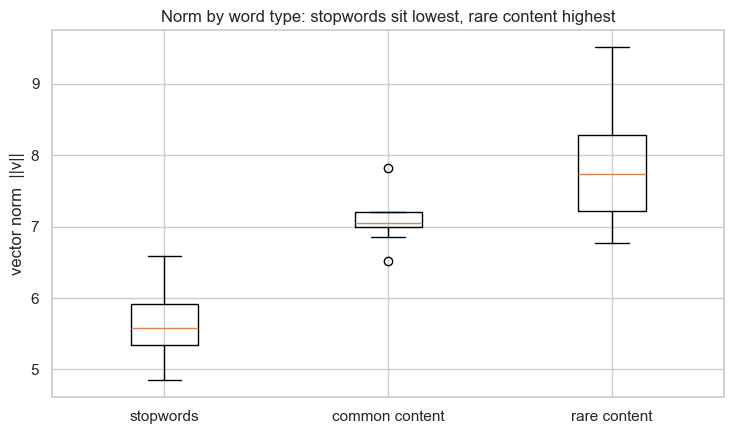

In [13]:
# The signal is clearest at the EXTREMES: stopwords vs rare content words.
stop = ['the', 'of', 'and', 'a', 'to', 'in', 'is', 'was', 'for', 'on', 'that', 'with', 'as', 'by', 'at', 'it']
rare = ['cytokine', 'photosynthesis', 'isotope', 'enzyme', 'algorithm',
        'tungsten', 'quartz', 'sediment', 'meridian', 'molecule']
content = ['mountain', 'guitar', 'doctor', 'planet', 'castle', 'engine', 'forest', 'coffee']

def norms(ws):
    return np.array([np.linalg.norm(get_vec(w)) for w in ws if get_vec(w) is not None])

groups = {'stopwords': norms(stop), 'common content': norms(content), 'rare content': norms(rare)}
for k, arr in groups.items():
    print(f'{k:<16} mean norm = {arr.mean():.2f}  (n={len(arr)})')

plt.figure(figsize=(7.5, 4.5))
plt.boxplot(list(groups.values()), tick_labels=list(groups.keys()))
plt.ylabel('vector norm  ||v||')
plt.title('Norm by word type: stopwords sit lowest, rare content highest')
plt.tight_layout(); plt.show()

In [14]:
# The top principal component as a 'common-ness' axis.
mixed = stop + rare
M = np.vstack([get_vec(w) for w in mixed])
Mc = M - M.mean(axis=0)
pca = PCA(n_components=5, random_state=42).fit(Mc)
pc1 = Mc @ pca.components_[0]

order = np.argsort(pc1)
print('Words sorted by PC1 score (the dominant direction):')
for i in order:
    tag = 'stopword' if mixed[i] in stop else 'rare'
    print(f'  {pc1[i]:+7.3f}  {mixed[i]:<16} ({tag})')
print(f'\nVariance explained: PC1 {pca.explained_variance_ratio_[0]:.1%}, PC2 {pca.explained_variance_ratio_[1]:.1%}')

Words sorted by PC1 score (the dominant direction):
   -2.620  on               (stopword)
   -2.526  at               (stopword)
   -2.461  for              (stopword)
   -2.421  was              (stopword)
   -2.294  a                (stopword)
   -2.287  with             (stopword)
   -2.287  the              (stopword)
   -2.276  to               (stopword)
   -2.201  in               (stopword)
   -2.190  it               (stopword)
   -2.099  and              (stopword)
   -1.993  of               (stopword)
   -1.978  that             (stopword)
   -1.956  by               (stopword)
   -1.905  as               (stopword)
   -1.617  is               (stopword)
   +0.632  meridian         (rare)
   +2.408  sediment         (rare)
   +2.469  algorithm        (rare)
   +2.828  quartz           (rare)
   +3.518  tungsten         (rare)
   +4.172  isotope          (rare)
   +4.239  cytokine         (rare)
   +4.362  molecule         (rare)
   +4.638  photosynthesis   (rare)
   +5.846

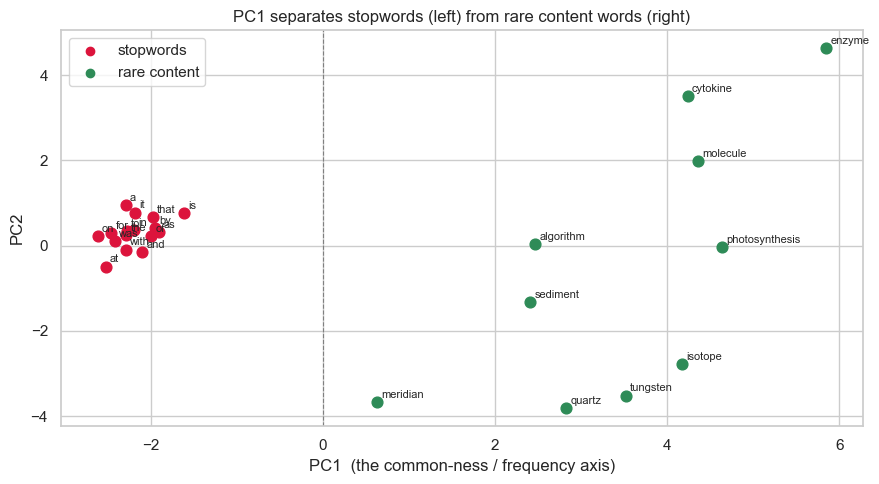

In [15]:
# Show PC1 separation visually (PC1 vs PC2)
pc2 = Mc @ pca.components_[1]
plt.figure(figsize=(9, 5))
for i, w in enumerate(mixed):
    color = 'crimson' if w in stop else 'seagreen'
    plt.scatter(pc1[i], pc2[i], color=color, s=60)
    plt.annotate(w, (pc1[i], pc2[i]), fontsize=8, xytext=(3, 3), textcoords='offset points')
plt.axvline(0, color='gray', ls='--', lw=0.8)
plt.xlabel('PC1  (the common-ness / frequency axis)'); plt.ylabel('PC2')
plt.title('PC1 separates stopwords (left) from rare content words (right)')
plt.scatter([], [], color='crimson', label='stopwords'); plt.scatter([], [], color='seagreen', label='rare content')
plt.legend(); plt.tight_layout(); plt.show()

### 🔎 What we see (read this carefully)

This is where a naive reading goes wrong, so let's be precise about what the numbers actually say:

- **The *global* norm–frequency correlation is weak.** Across 5000 words the Spearman is only ~0.1, and the decile chart is nearly flat. So you **cannot** claim 'frequent ⇒ small norm' as a smooth law in GloVe.
- **But at the extremes the signal is clear.** *Stopwords* have the **lowest** norms, *rare content words* the **highest** — a real, ordered gap. Word length is uncorrelated (control ≈ 0), so this isn't a length artefact.
- **PC1 is a 'common-ness' axis.** The single dominant PCA direction cleanly separates stopwords from rare content words — exactly Mu & Viswanath's (2018) observation that the top component encodes frequency/common information rather than topic.

> 🧠 **Interpretation.** The norm is contaminated by *word type / frequency*, which is **not** what we want a similarity to depend on. That's the real argument for (a) comparing by **direction** and (b) optionally removing the **top PCA component** ('all-but-the-top') to strip the shared common-ness direction before measuring similarity.

> ⚠️ Direction is model-dependent: in **GloVe** stopwords have the smallest norms; in **skip-gram word2vec** (Schakel & Wilson, 2015) the *frequent* words have the largest. The conclusion is the same either way — **the norm is a frequency artefact, not meaning.**

## ✅ Conclusion

On real 300-D GloVe vectors we proved every static-embedding claim from the slides — and pinned down the honest version of the subtle one:

| Claim | What we showed |
|---|---|
| Direction carries meaning | 2-D clusters **and** analogies (king−man+woman→queen) |
| Curse of dimensionality | L2 contrast collapses *and* cosine spread shrinks |
| Normalization is the lever | cosine ≡ normalized-L2 ranking across 8 queries; raw L2 always lower |
| Norm is a frequency artefact | weak global trend, but clear stopword < content < rare ordering; length uncorrelated |
| PCA frequency axis | PC1 separates stopwords from rare content (the all-but-the-top direction) |

**Bottom line:** compare static embeddings by **direction** (cosine), normalize if you want to use L2, and strip the **top PCA component** when you need the cleanest semantics.